In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Sex        female       male
Pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669


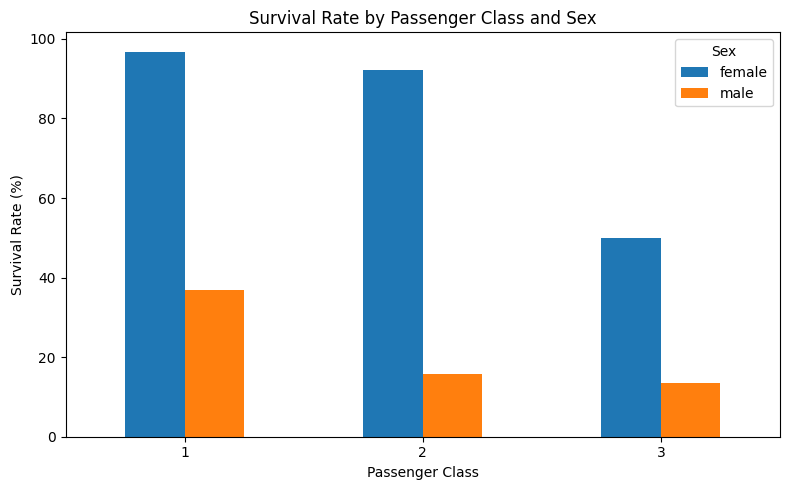

In [41]:
survival_pivot = train_df.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc='mean') * 100
print(survival_pivot)
survival_pivot.plot(kind='bar', figsize=(8, 5))
plt.title('Survival Rate by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

Women had a higher overall survival rate than men.
“First-class passengers had the highest survival rate, followed by second-class and then third-class passengers. Overall, male passengers had the lowest survival rate.”

Sex     female  male
Pclass              
1            7     4
2           12     9
3           19    10


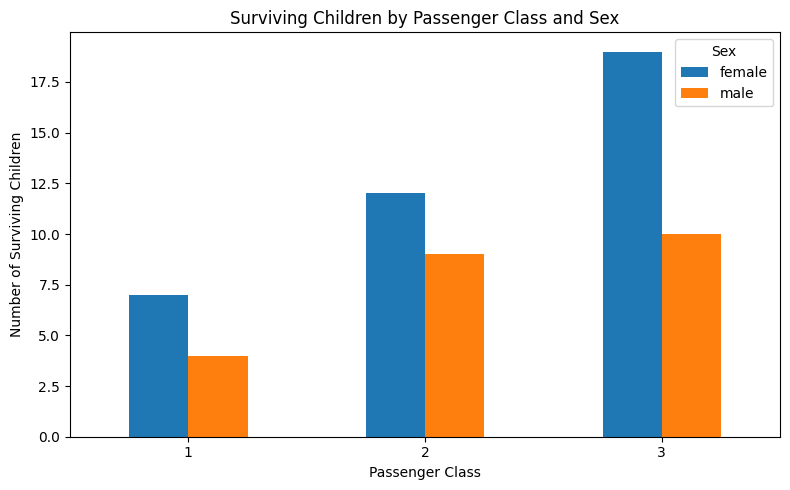

In [52]:
train ['Is_Child'] = train['Age'] < 18
train.groupby(['Is_Child', 'Sex'])['Survived'].mean() * 100
child_survivors = train[
    (train['Is_Child']) & (train['Survived'] == 1)
]

child_pivot = child_survivors.pivot_table(
    index='Pclass',
    columns='Sex',
    values='PassengerId',
    aggfunc='count',
    fill_value=0
)
print(child_pivot)
child_pivot.plot(kind='bar', figsize=(8, 5))
plt.title('Surviving Children by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Surviving Children')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

“Female children had a higher survival rate. However, the majority of surviving children were passengers from third class.”
note: “Third-class passengers were the largest passenger group.”

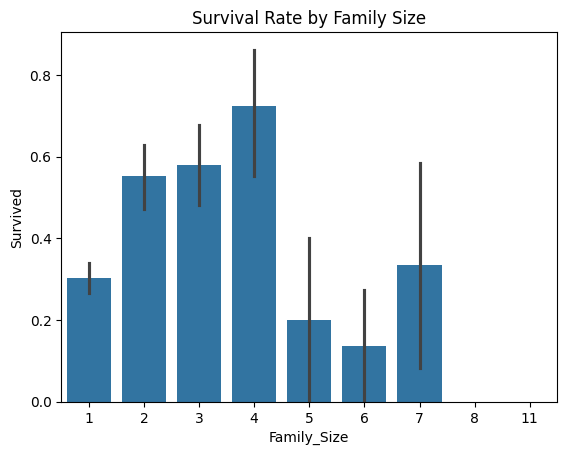

In [55]:
train['Family_Size'] = train['SibSp'] + train['Parch'] + 1
sns.barplot(x='Family_Size', y='Survived', data=(train))
plt.title('Survival Rate by Family Size')
plt.show()

Survival Rate by Family Size

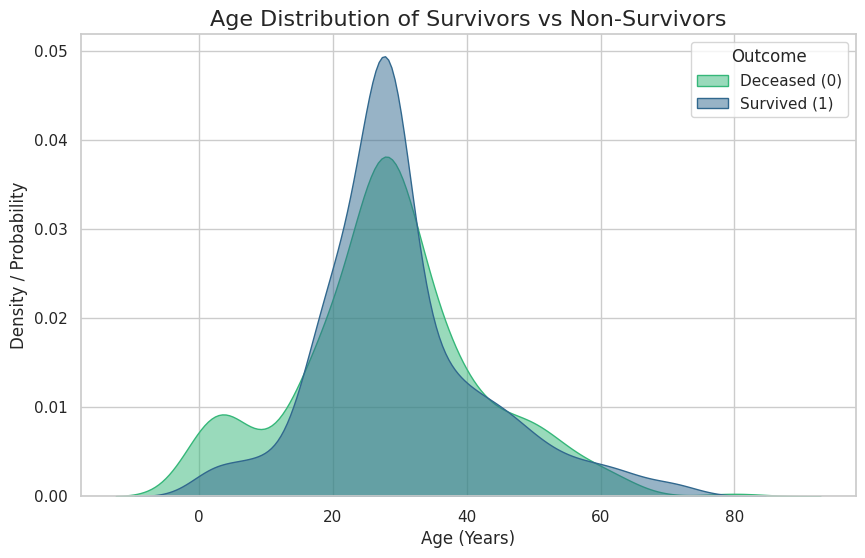

In [56]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_df, x='Age', hue='Survived', fill=True, common_norm=False, palette='viridis', alpha=.5)
plt.title('Age Distribution of Survivors vs Non-Survivors', fontsize=16)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Density / Probability', fontsize=12)
plt.legend(title='Outcome', labels=['Deceased (0)', 'Survived (1)'])
plt.show()